# imports e requesitos

In [1]:
! pip install ultralytics
! pip install opencv-python
! pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Guilherme\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Guilherme\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Guilherme\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
import cv2
import torch
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO
from IPython.display import Image, display

# Carregando dataset e treinando modelo

In [3]:
torch.cuda.empty_cache()

# Isso vai imprimir quanto de memória a placa tem livre agora.
print(f"Memória Alocada: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Memória Livre: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

Memória Alocada: 0.00 GB
Memória Livre: 0.00 GB


In [4]:
CAMINHO_DO_DATASET = "waste detection.v1i.yolov8/data.yaml"

# Carrega os pesos iniciais do YOLOv10-Nano
model = YOLO("yolov10n.pt")

# treinamento estruturado com fine tuning
results_train = model.train(
    data=CAMINHO_DO_DATASET,
    project="teste_lixo_normal",
    name="yolov10n_lixo_normal_finetune",
    
    # --- Parâmetros de Hardware e Tempo ---
    epochs=150,
    patience=20,
    batch=16,
    imgsz=640,
    device="cuda",
    amp=True,
        
    # --- Melhor Fine Tunning ---
    freeze=10,           # Congela a base para aproveitar o conhecimento "fábrica" do YOLO
    dropout=0.2,        
    weight_decay=0.0005, 
    
    # --- Otimizador ---
    optimizer='AdamW', 
    cos_lr=True,       
    lr0=0.001,         
    
    # --- AUGMENTATION PARA LIXO NORMAL ---
    mosaic=1.0,    
    fliplr=0.5,    
    scale=0.5,     
    translate=0.1, 
    hsv_s=0.3,     
    hsv_v=0.3      
)

Ultralytics 8.4.56  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=waste detection.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10n_lixo_normal_finetune-2, nbs=64, nms=False, opset=None, optimize=Fal

# Inferência no conjunto de teste

In [ ]:
# Carrega o melhor modelo gerado no treinamento anterior
melhor_modelo_path = "runs/detect/teste_lixo_normal/yolov10n_lixo_normal_finetune/weights/best.pt"
model_treinado = YOLO(melhor_modelo_path)

# Conjunto de teste
pasta_imagens_teste = "waste detection.v1i.yolov8/test/images"

# Fazendo a inferência e salvando as imagens com as bounding boxes desenhadas
predicoes = model_treinado.predict(
    source=pasta_imagens_teste,
    conf=0.5, # valor de confiança mínimo para considerar uma detecção válida
    save=True,  # Salva as imagens com as bounding boxes desenhadas
    project="Automacao_Triagem",
    name="resultados_teste_visual",
)

print(
    f"Inferência concluída! As imagens com as caixas foram salvas em: {predicoes[0].save_dir}"
)


image 1/252 c:\Users\Guilherme\Desktop\VISUAL STUDIO CODE\aprendizagem profunda\Projeto_reciclagem_aprendizagem_profunda\waste detection.v1i.yolov8\test\images\cardboard120_jpg.rf.cXckDEv2Ygs5M9xt7iJl.jpg: 480x640 (no detections), 22.3ms
image 2/252 c:\Users\Guilherme\Desktop\VISUAL STUDIO CODE\aprendizagem profunda\Projeto_reciclagem_aprendizagem_profunda\waste detection.v1i.yolov8\test\images\cardboard130_jpg.rf.YIXfa88ECzQbyHMP4xIH.jpg: 480x640 1 cardboard, 21.9ms
image 3/252 c:\Users\Guilherme\Desktop\VISUAL STUDIO CODE\aprendizagem profunda\Projeto_reciclagem_aprendizagem_profunda\waste detection.v1i.yolov8\test\images\cardboard133_jpg.rf.h88RRDwKfiq27np0Q8ZW.jpg: 480x640 1 paper, 22.8ms
image 4/252 c:\Users\Guilherme\Desktop\VISUAL STUDIO CODE\aprendizagem profunda\Projeto_reciclagem_aprendizagem_profunda\waste detection.v1i.yolov8\test\images\cardboard142_jpg.rf.0qlwvl23j8Jmh3bqRucc.jpg: 480x640 1 cardboard, 26.1ms
image 5/252 c:\Users\Guilherme\Desktop\VISUAL STUDIO CODE\apren

# Visualização no conjunto de testes

Total de imagens encontradas: 252



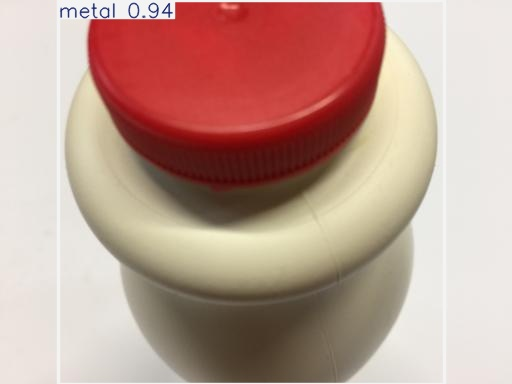

--------------------------------------------------------------------------------



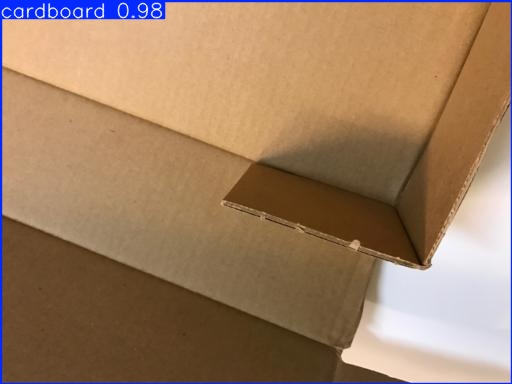

--------------------------------------------------------------------------------



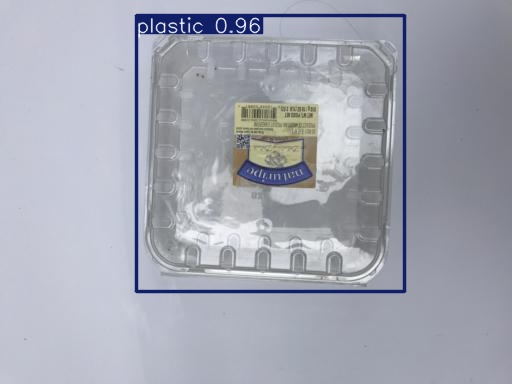

--------------------------------------------------------------------------------



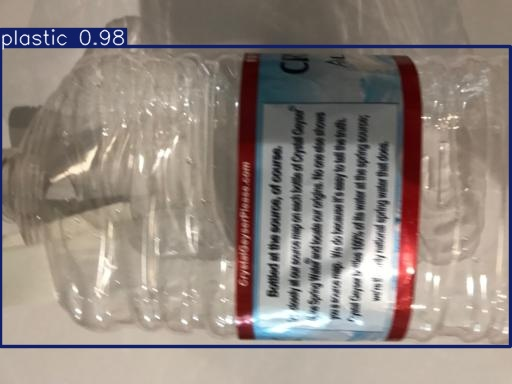

--------------------------------------------------------------------------------



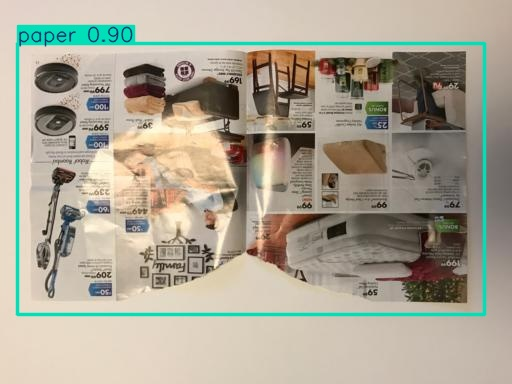

--------------------------------------------------------------------------------



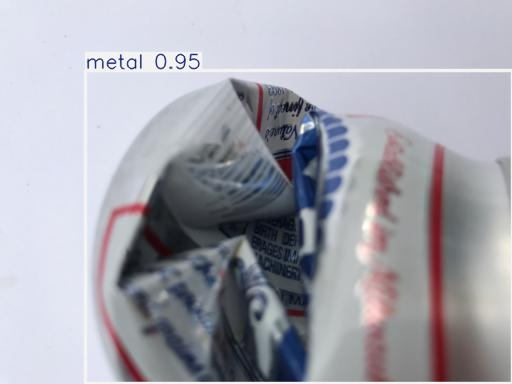

--------------------------------------------------------------------------------



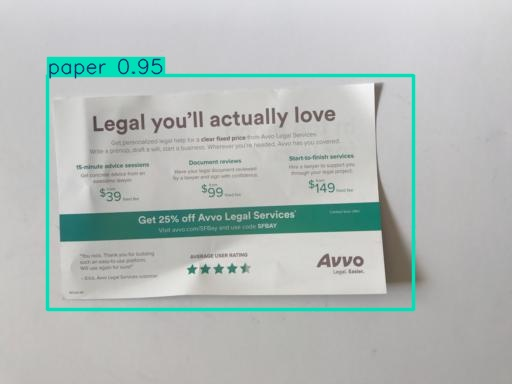

--------------------------------------------------------------------------------



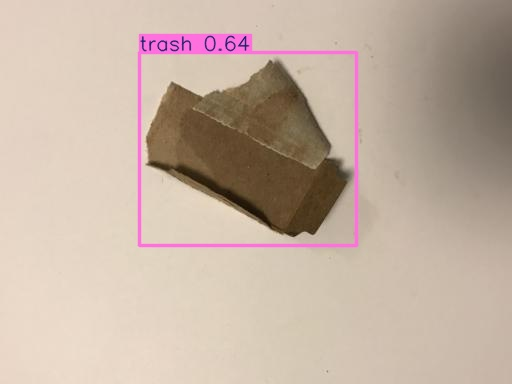

--------------------------------------------------------------------------------



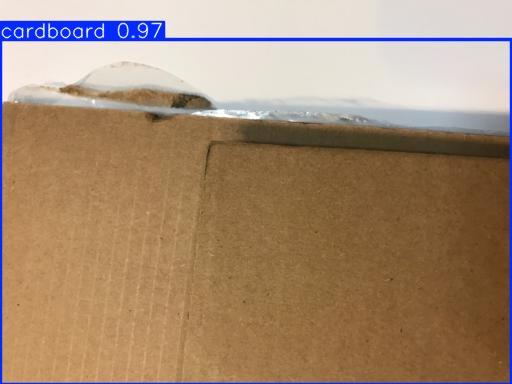

--------------------------------------------------------------------------------



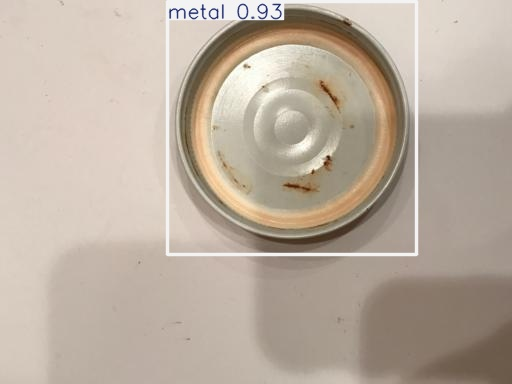

--------------------------------------------------------------------------------



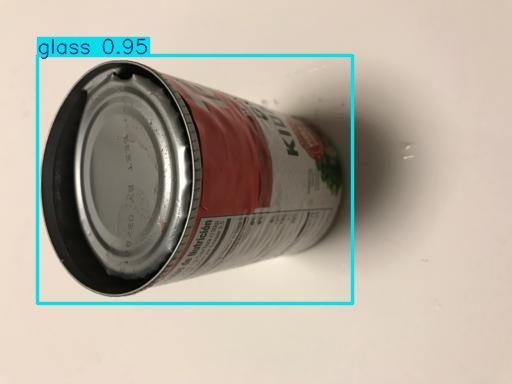

--------------------------------------------------------------------------------



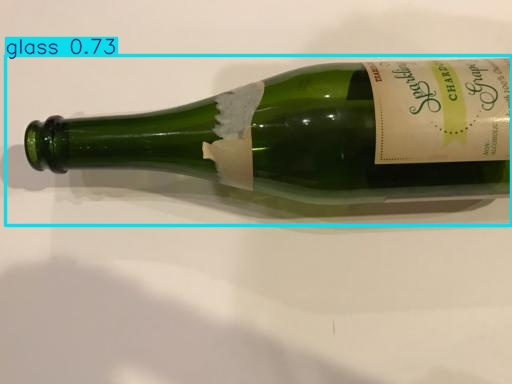

--------------------------------------------------------------------------------



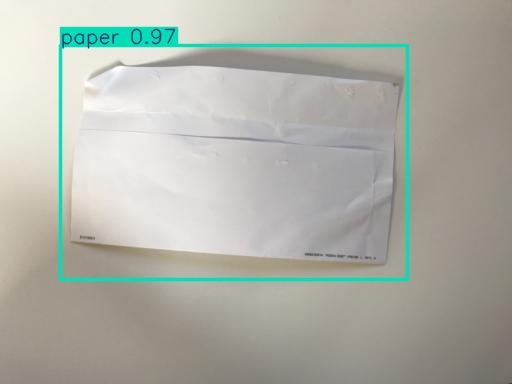

--------------------------------------------------------------------------------



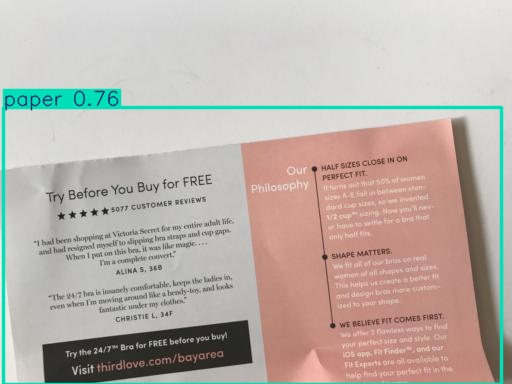

--------------------------------------------------------------------------------



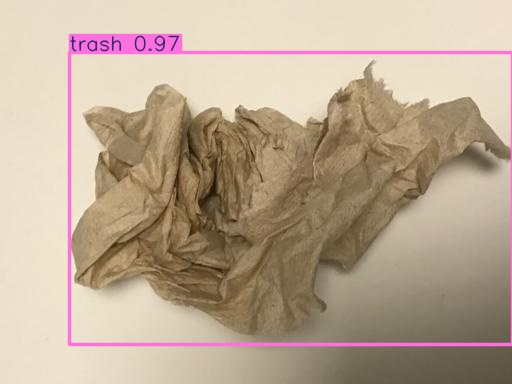

--------------------------------------------------------------------------------



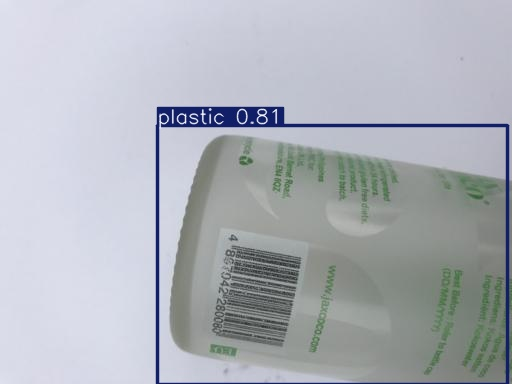

--------------------------------------------------------------------------------



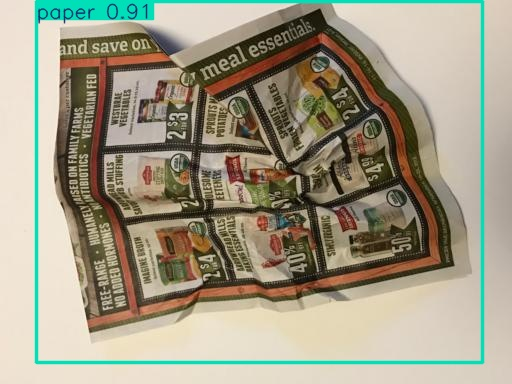

--------------------------------------------------------------------------------



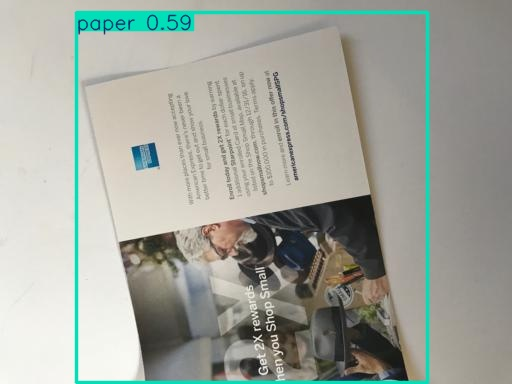

--------------------------------------------------------------------------------



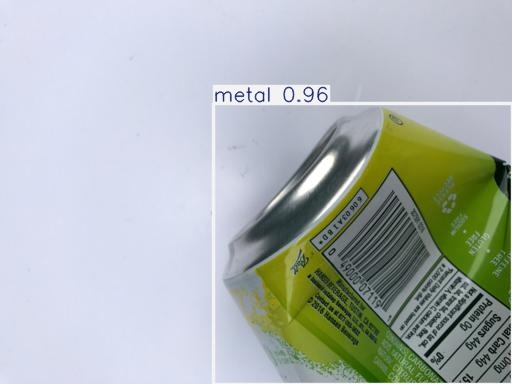

--------------------------------------------------------------------------------



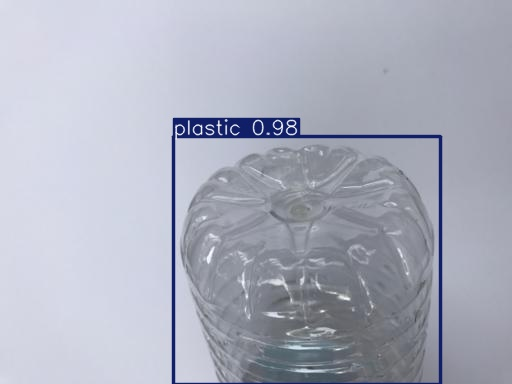

--------------------------------------------------------------------------------



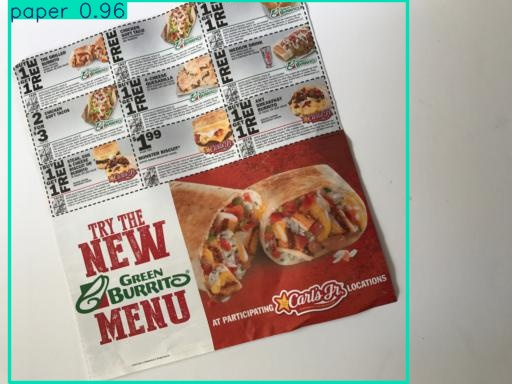

--------------------------------------------------------------------------------



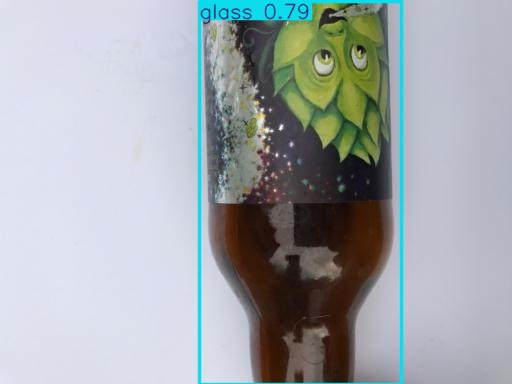

--------------------------------------------------------------------------------



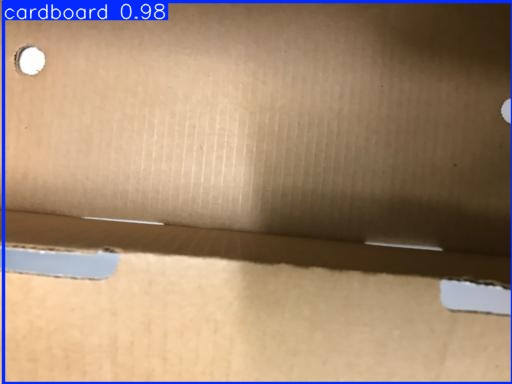

--------------------------------------------------------------------------------



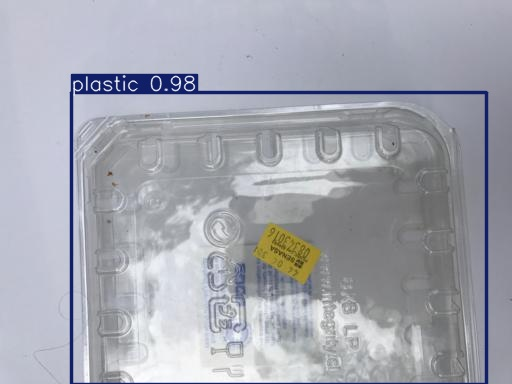

--------------------------------------------------------------------------------



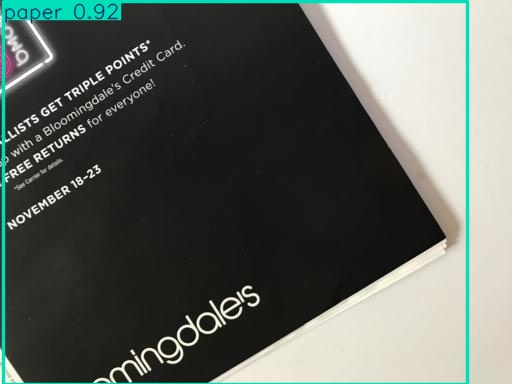

--------------------------------------------------------------------------------



In [9]:
diretorio_saida = predicoes[0].save_dir

# Busca por todas as imagens processadas
imagens_processadas = glob.glob(os.path.join(diretorio_saida, "*.jpg")) + \
                      glob.glob(os.path.join(diretorio_saida, "*.png")) + \
                      glob.glob(os.path.join(diretorio_saida, "*.jpeg")) 

total_imagens = len(imagens_processadas)
print(f"Total de imagens encontradas: {total_imagens}\n")

limite_exibicao = 25

if total_imagens > 0:
    # Garante que não vamos tentar pegar mais imagens do que existem na pasta
    quantidade_para_exibir = min(limite_exibicao, total_imagens)
    
    # Pega uma amostragem aleatória única (sem repetições)
    imagens_aleatorias = random.sample(imagens_processadas, quantidade_para_exibir)

    # Exibe as imagens sorteadas
    for i, caminho_img in enumerate(imagens_aleatorias):
        display(Image(filename=caminho_img, width=400))
        print("-" * 80 + "\n")
else:
    print("Nenhuma imagem encontrada no diretório.")

# Métricas finais

Foram encontradas 8 imagens de métricas e distribuições.

Gráfico: Boxf1 Curve


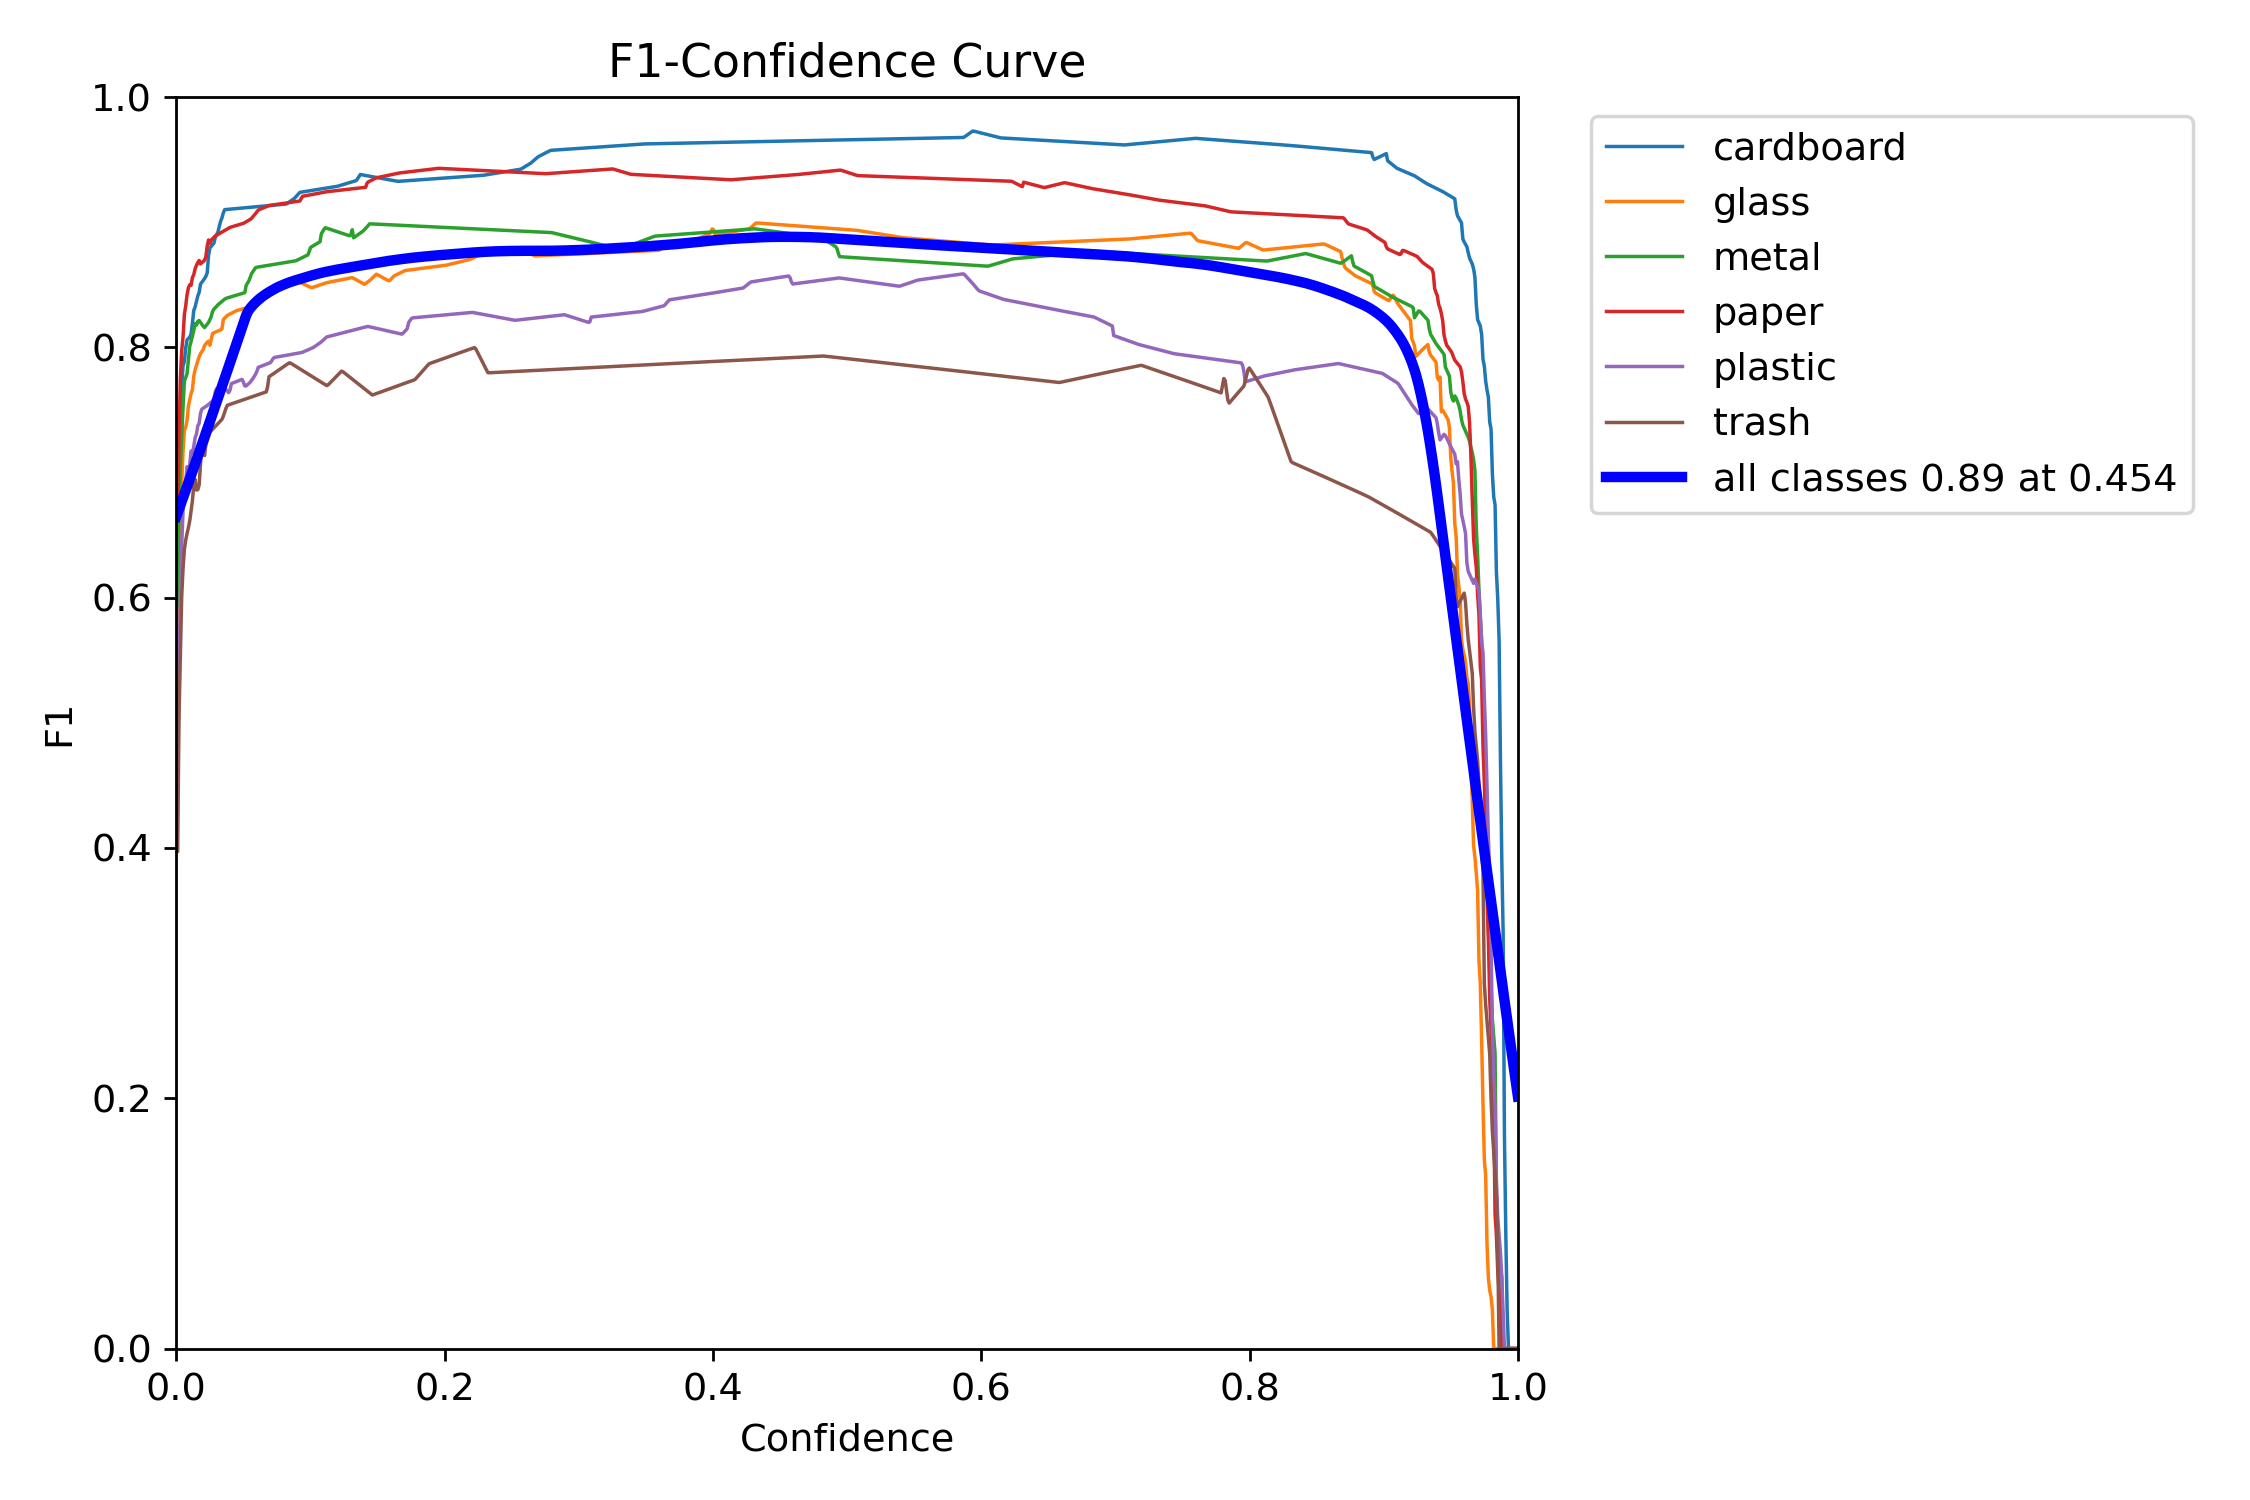

--------------------------------------------------------------------------------

Gráfico: Boxpr Curve


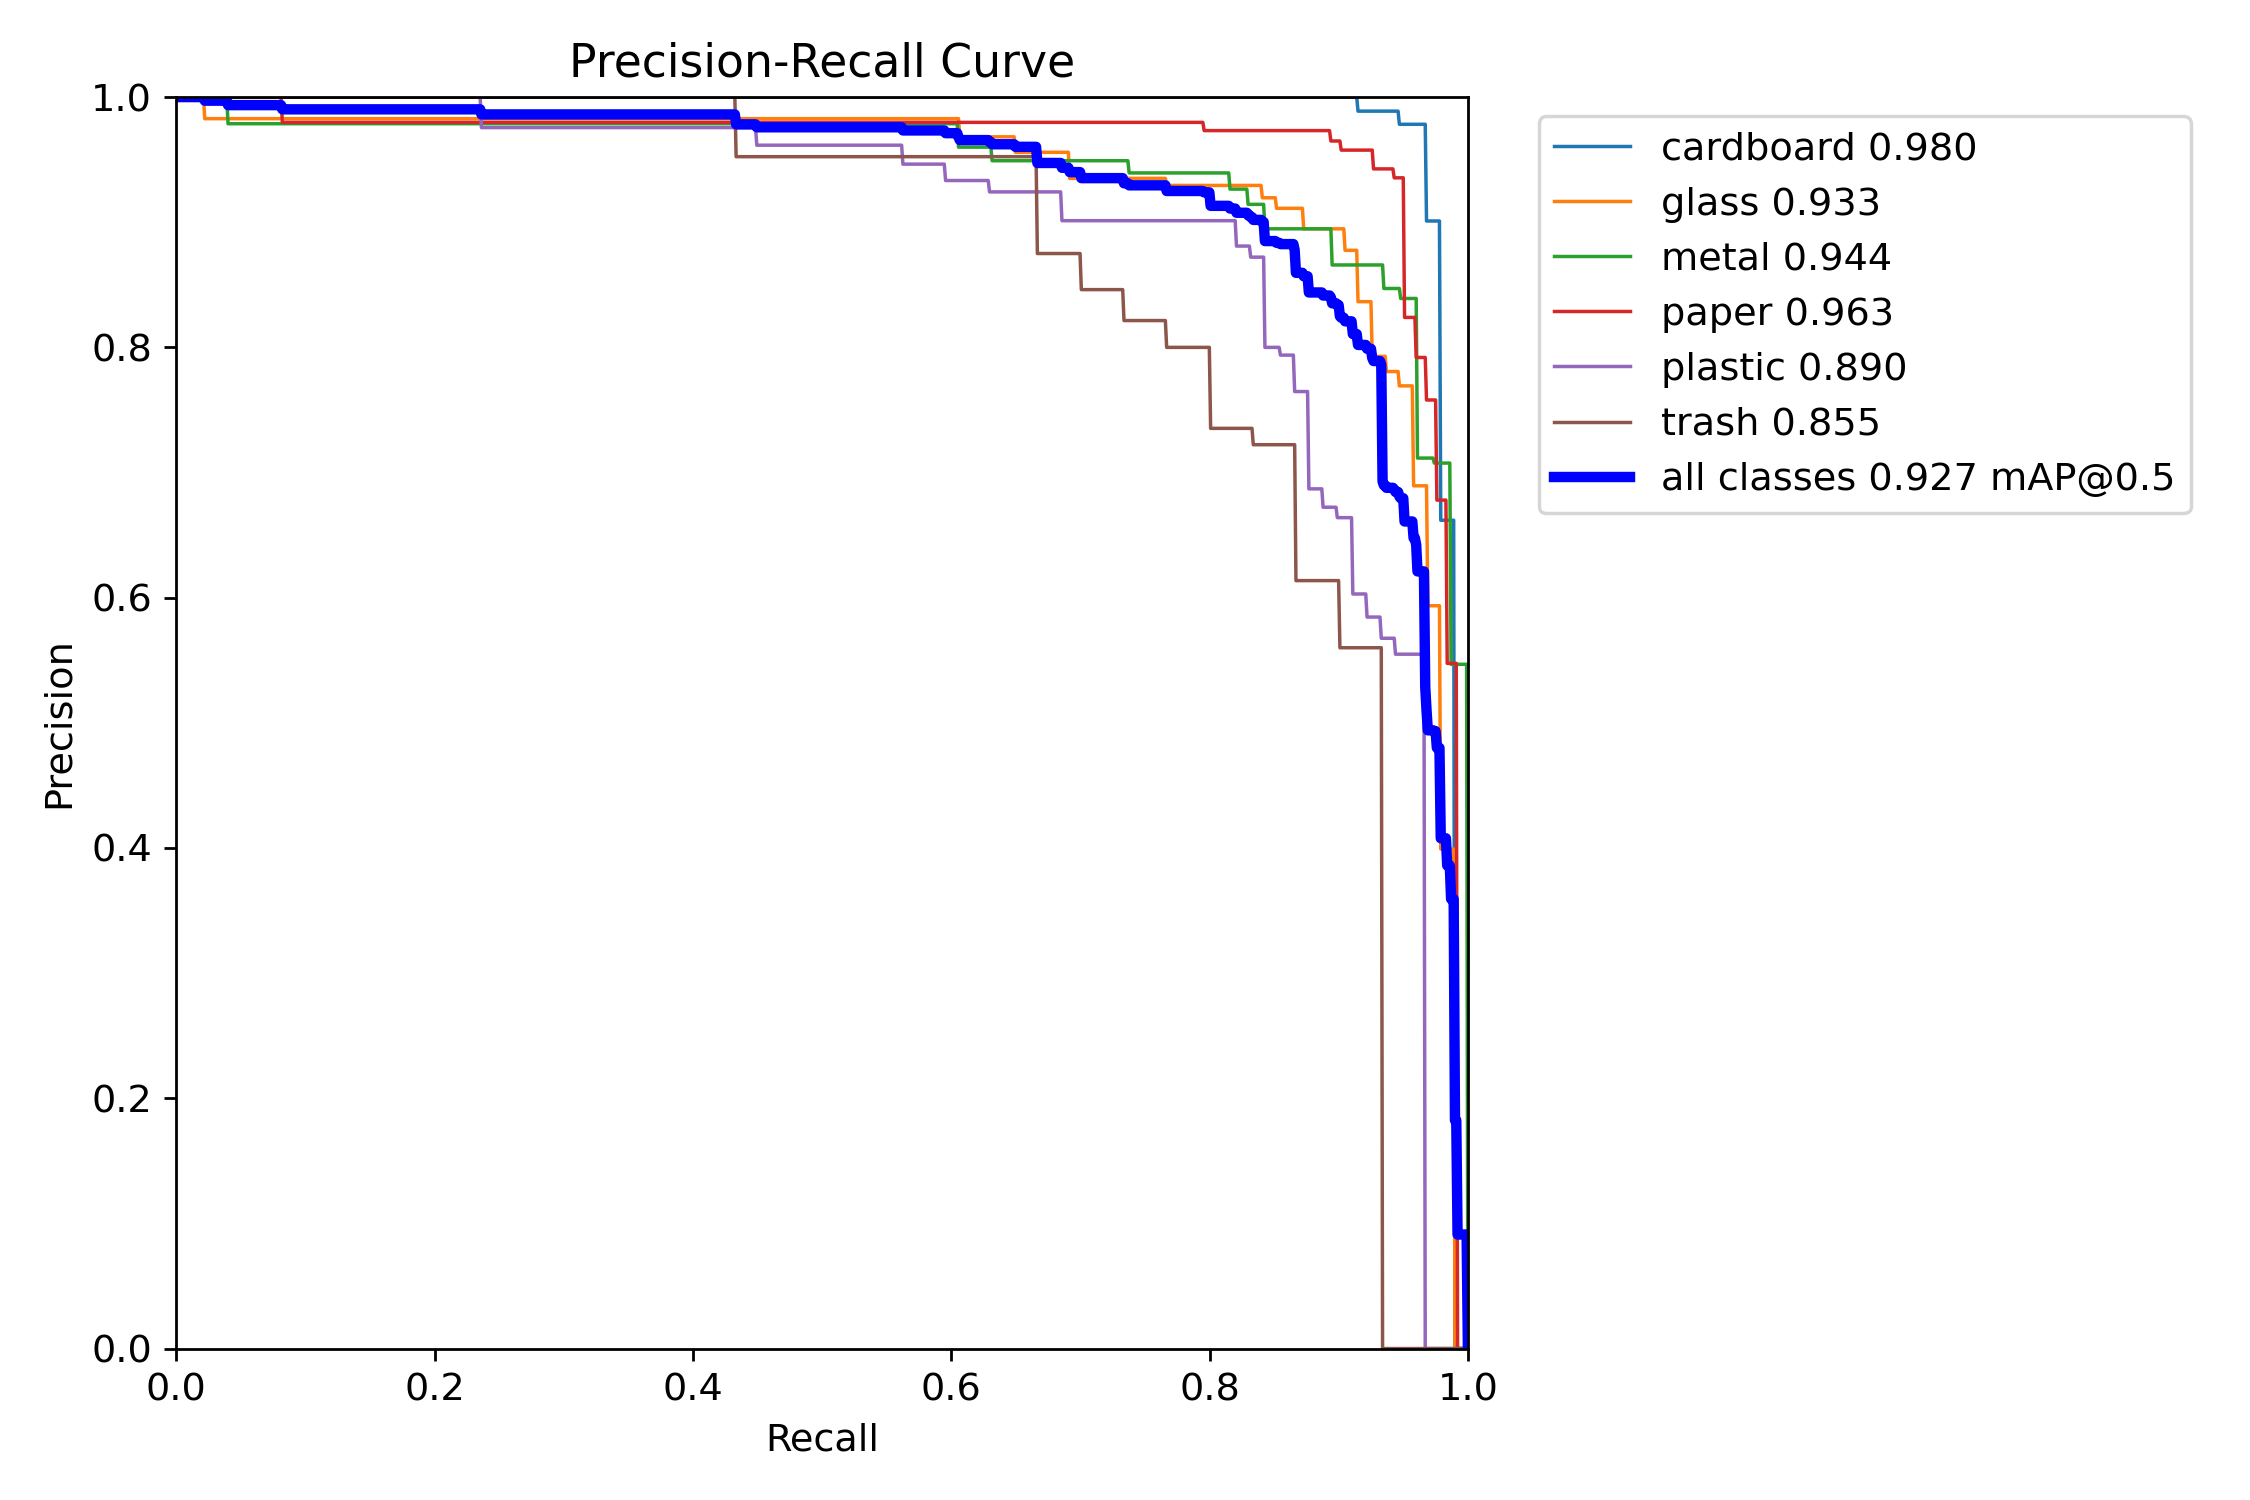

--------------------------------------------------------------------------------

Gráfico: Boxp Curve


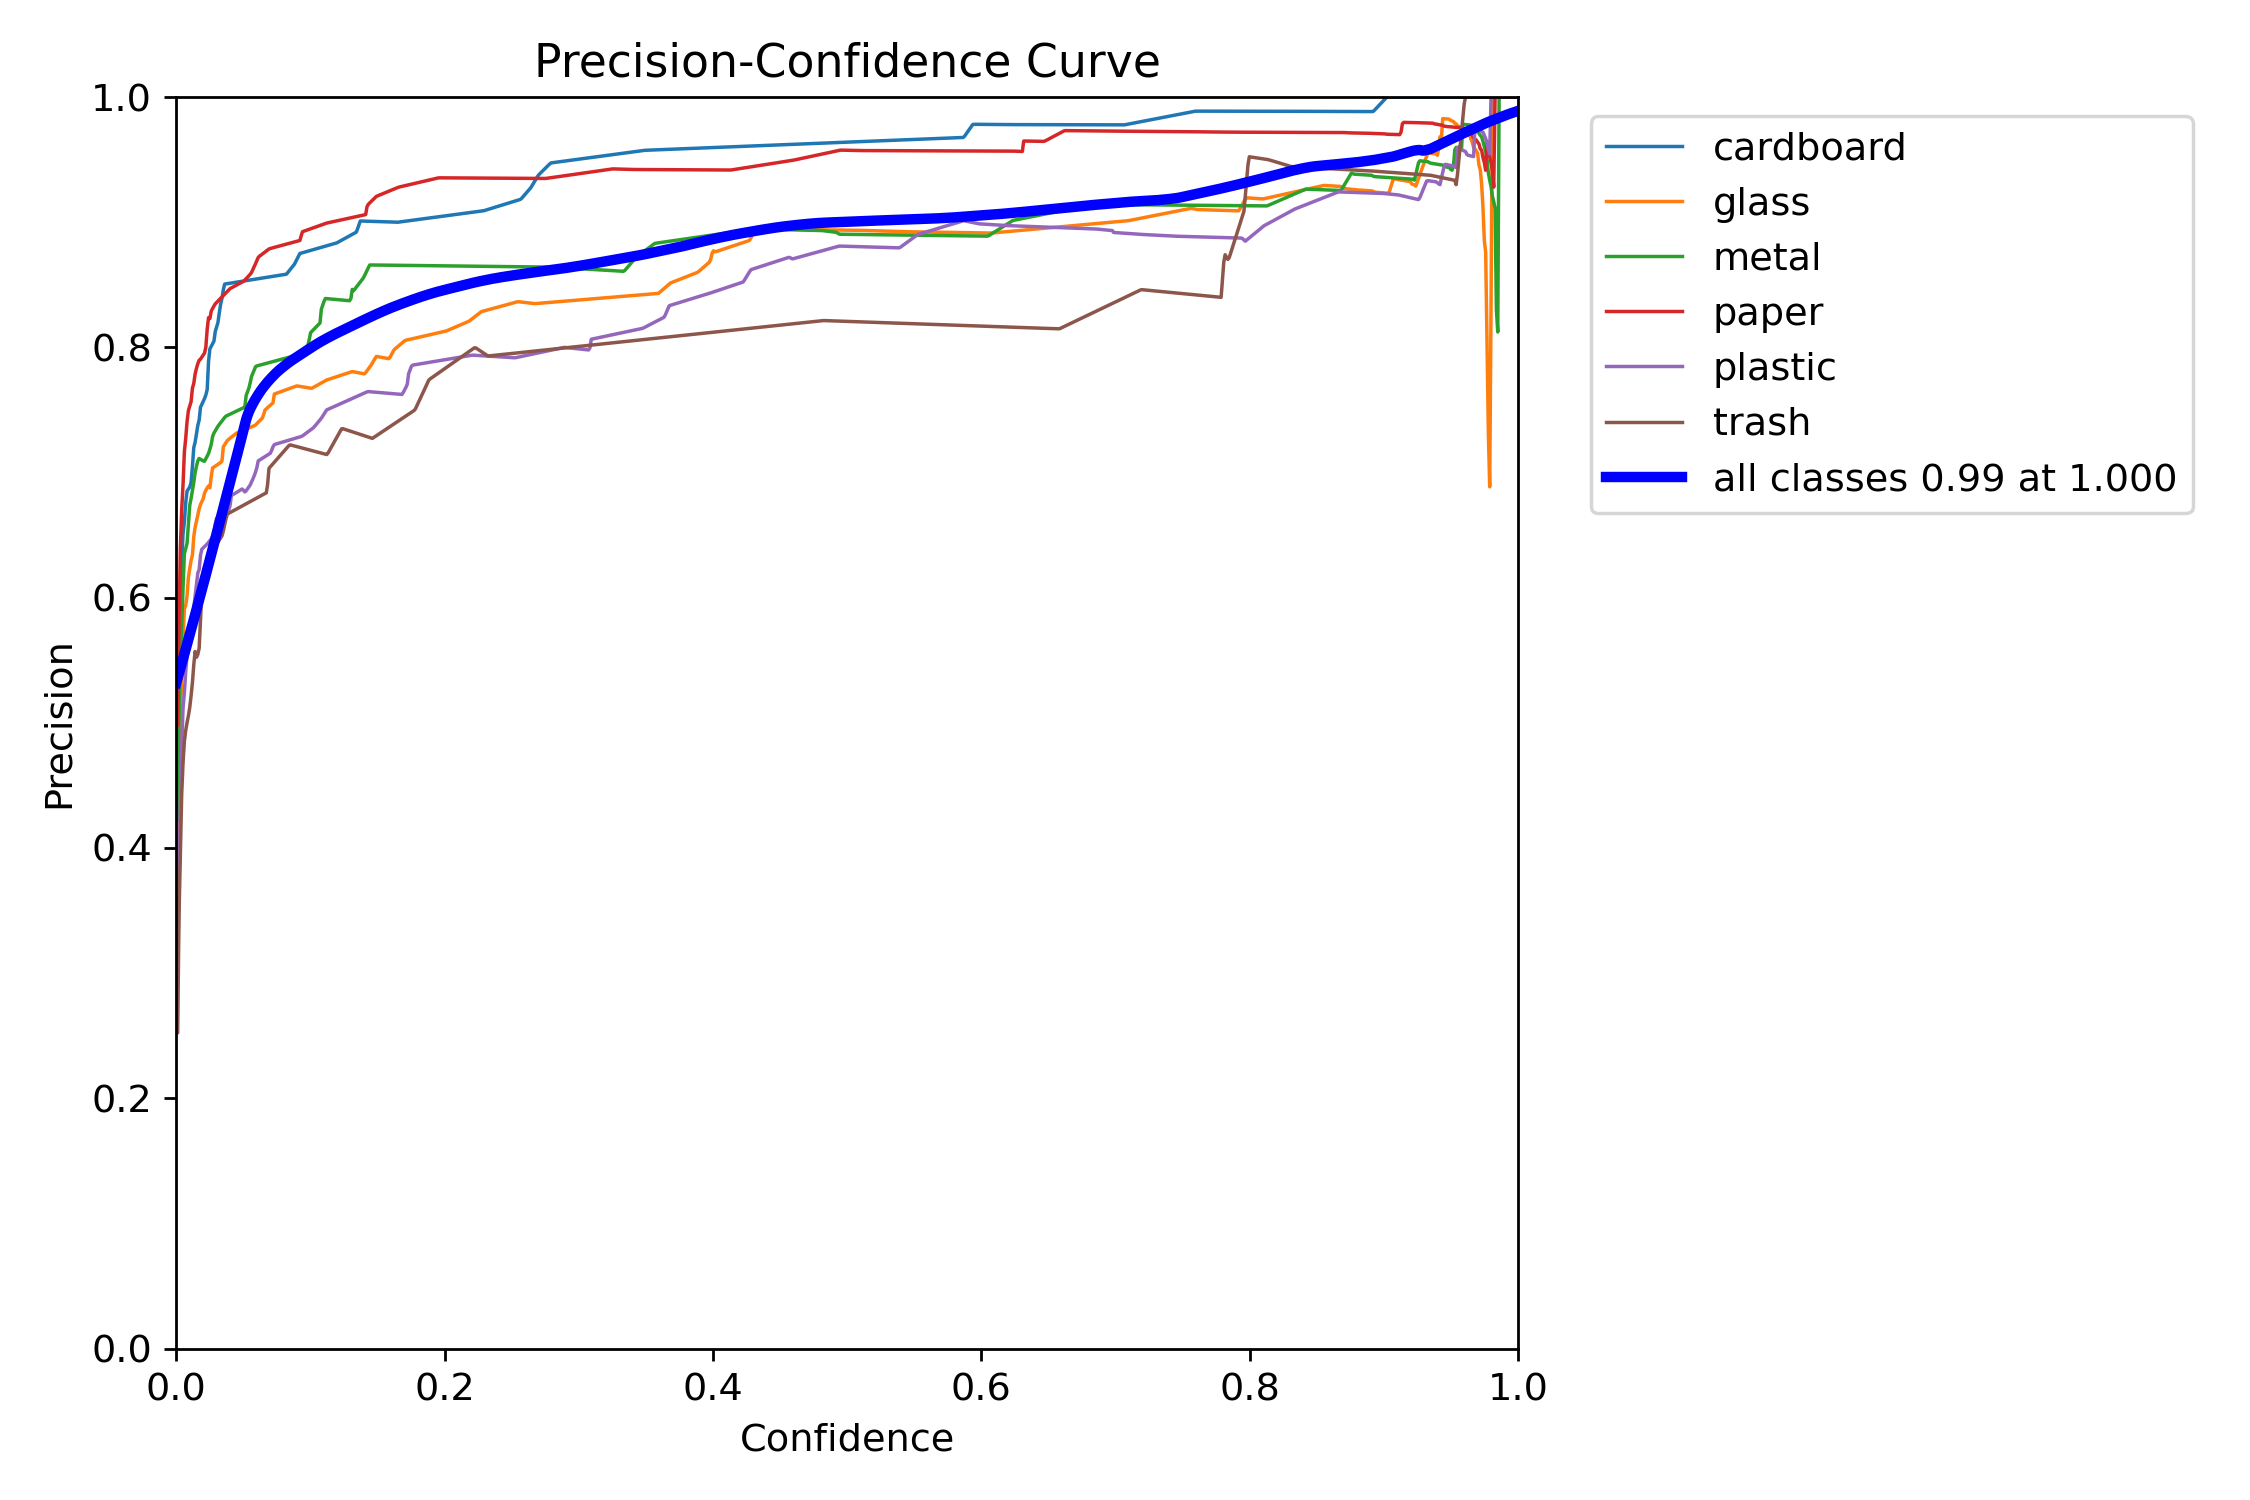

--------------------------------------------------------------------------------

Gráfico: Boxr Curve


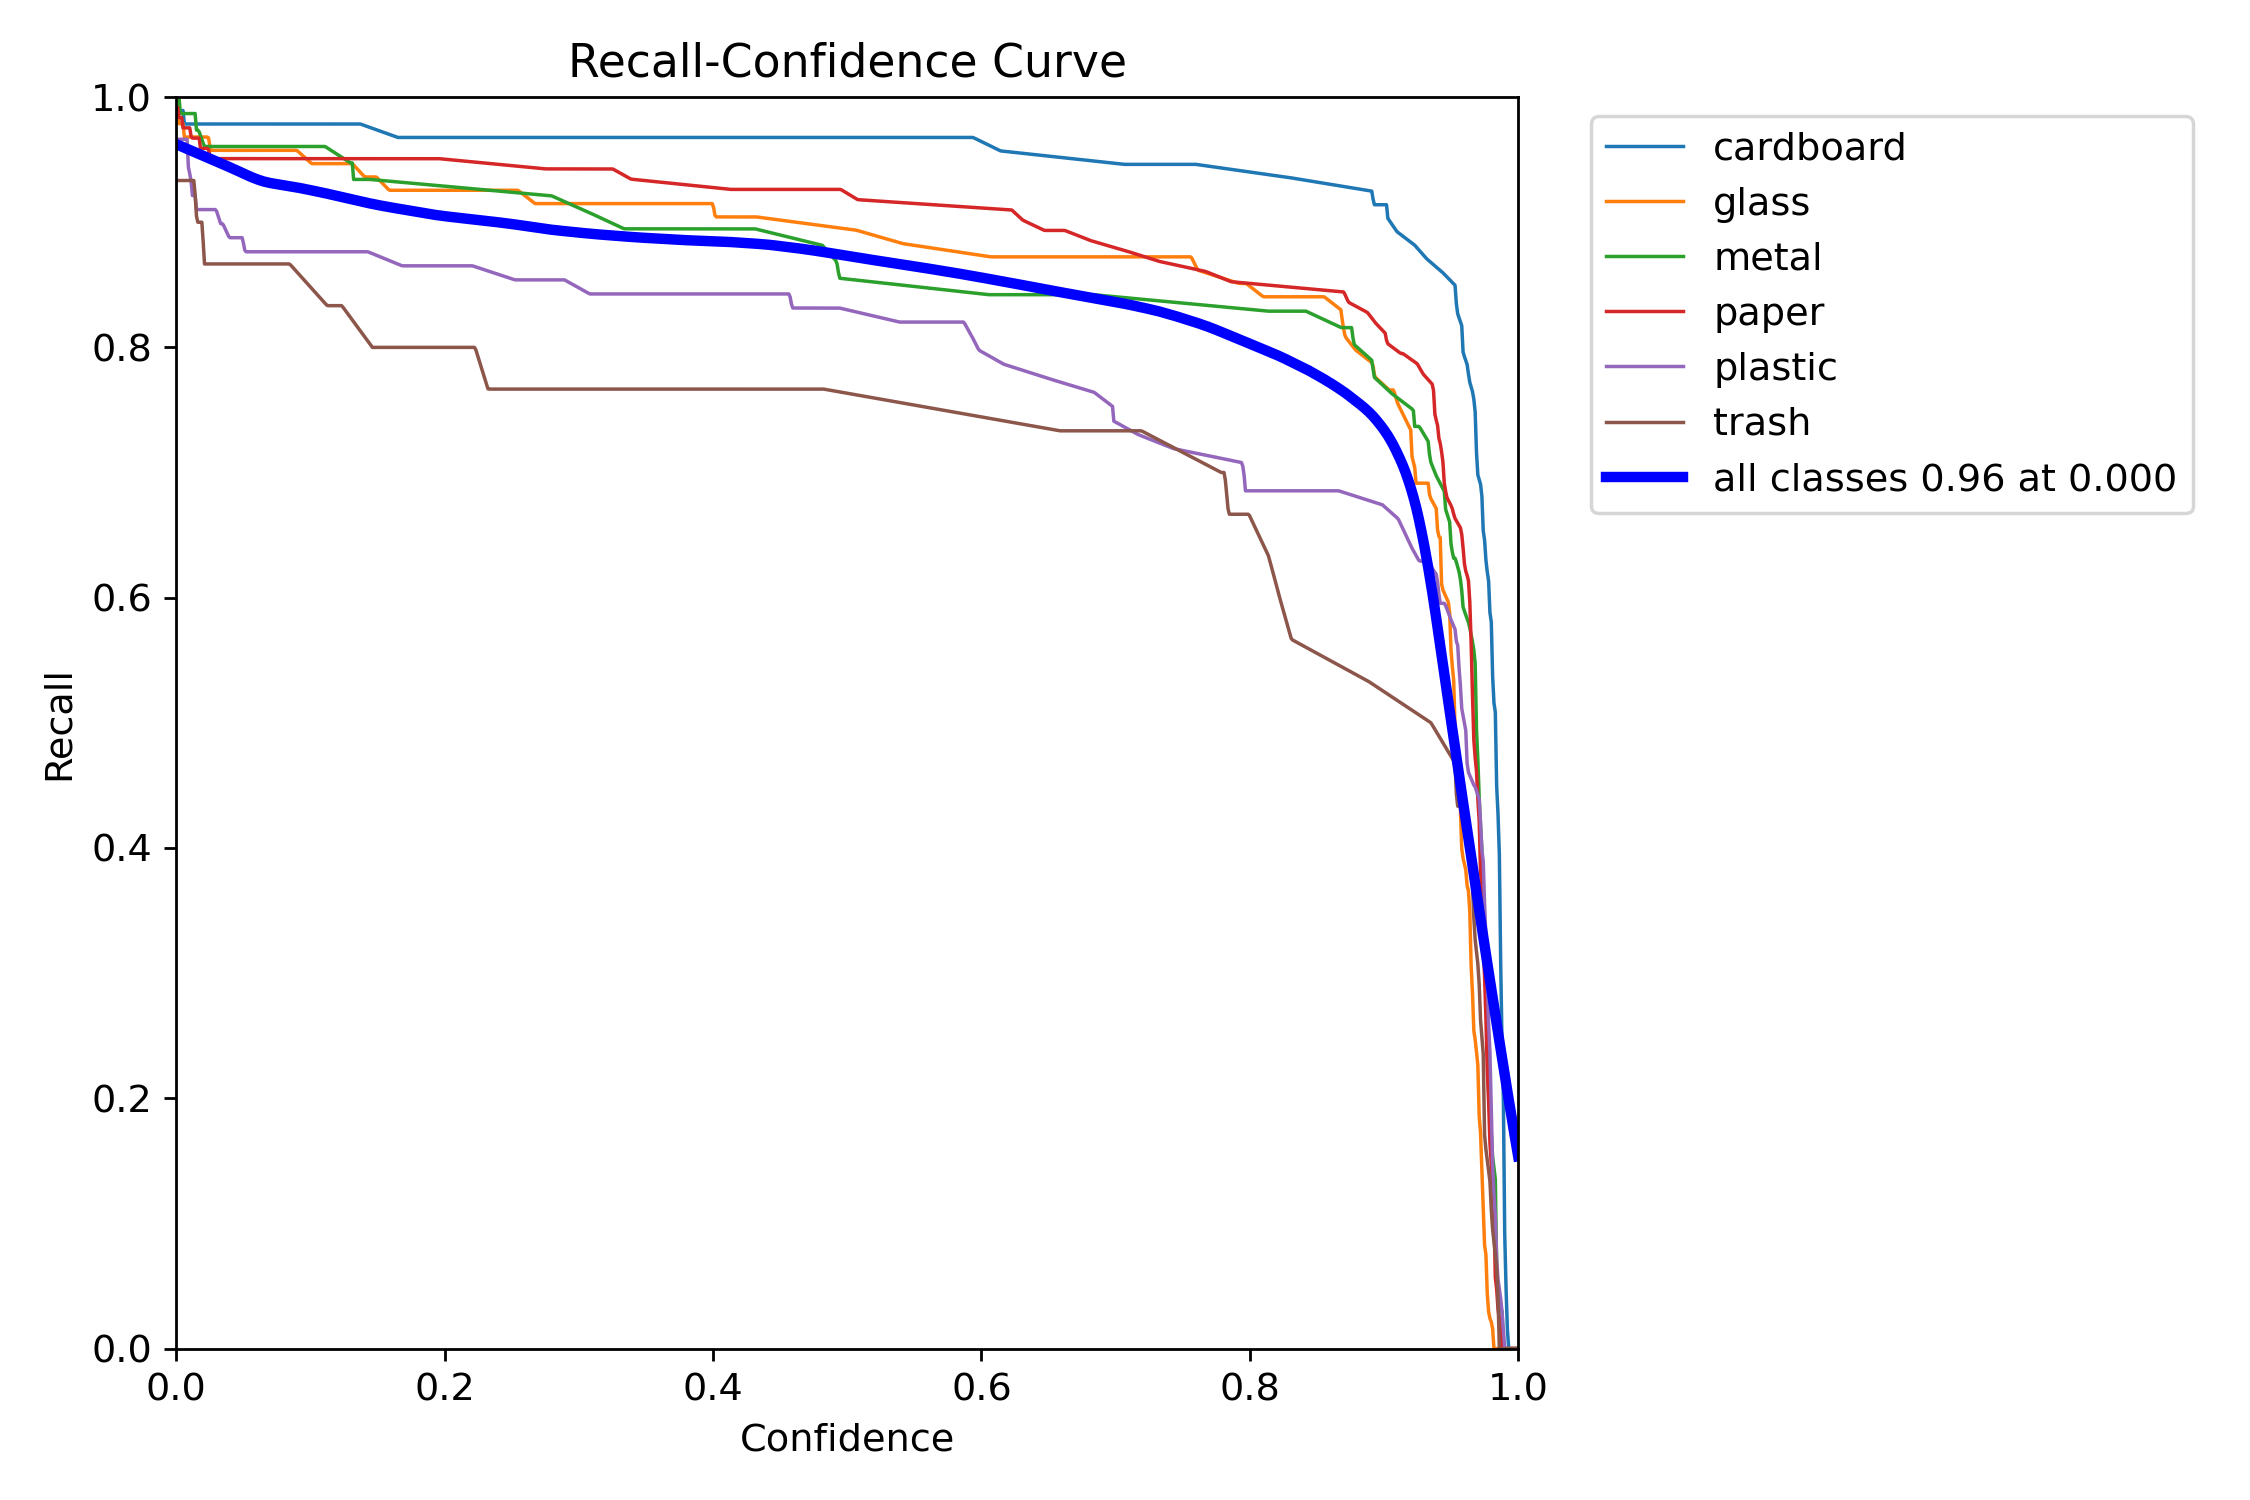

--------------------------------------------------------------------------------

Gráfico: Confusion Matrix


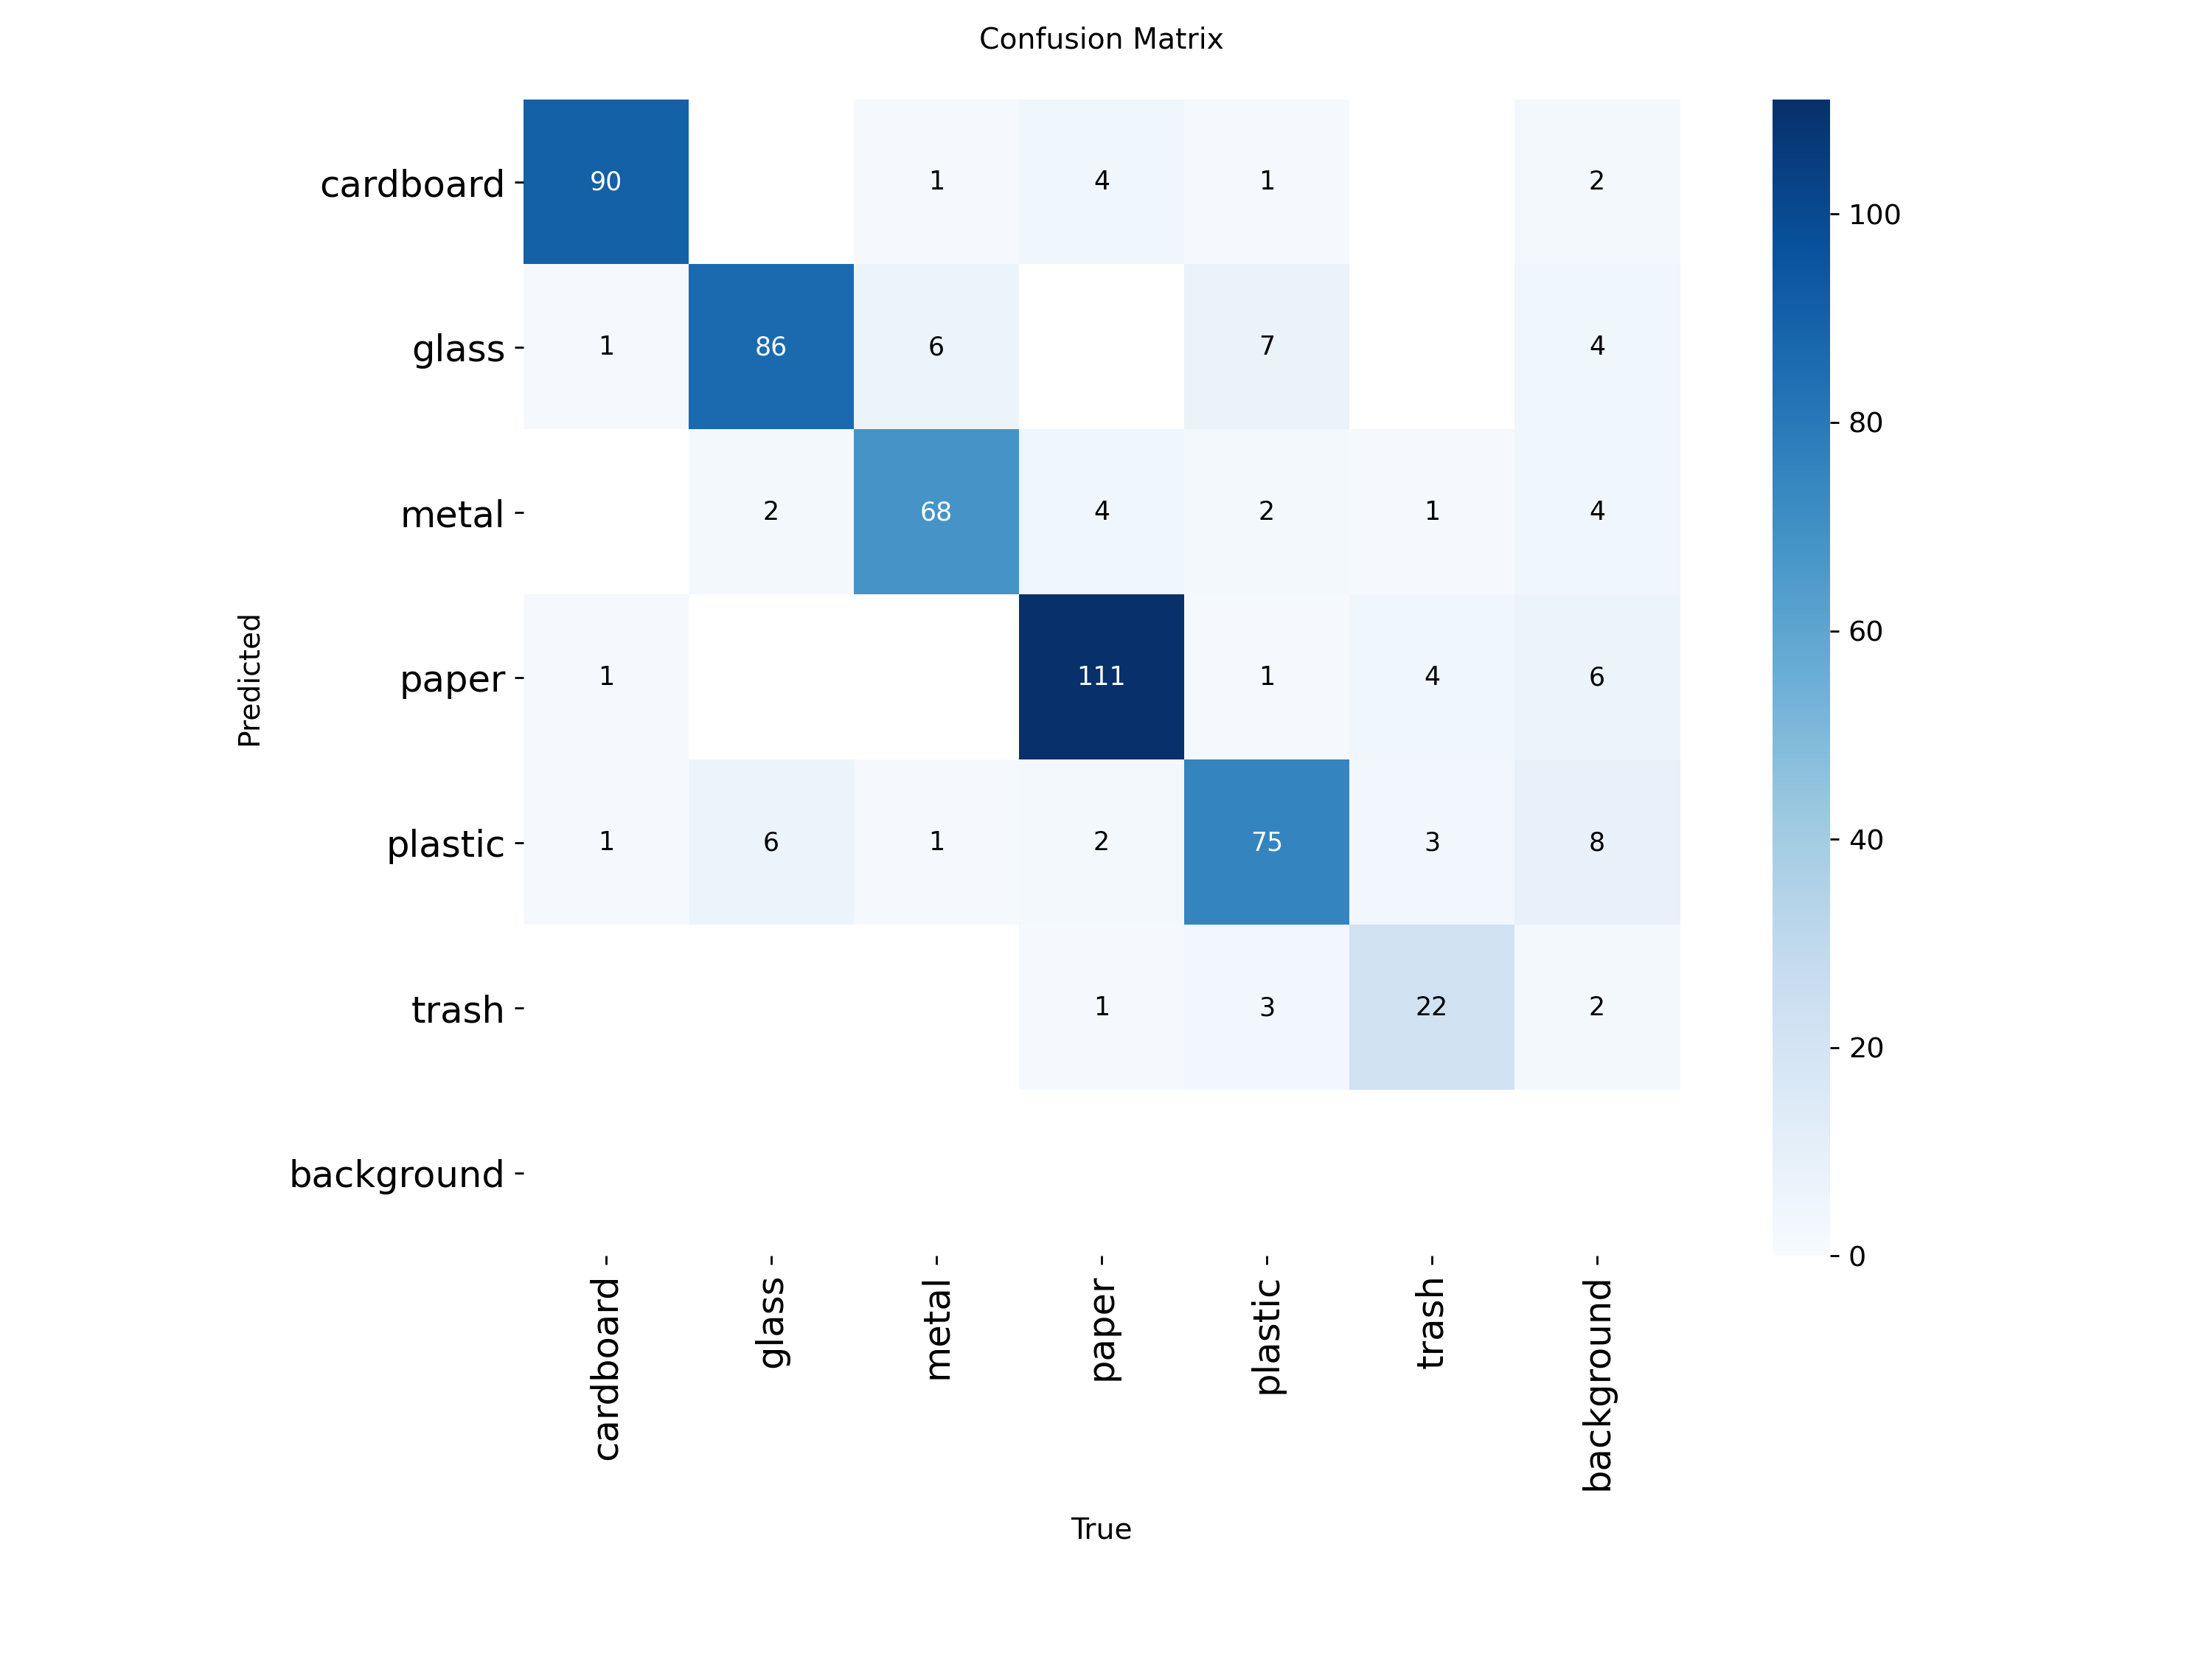

--------------------------------------------------------------------------------

Gráfico: Confusion Matrix Normalized


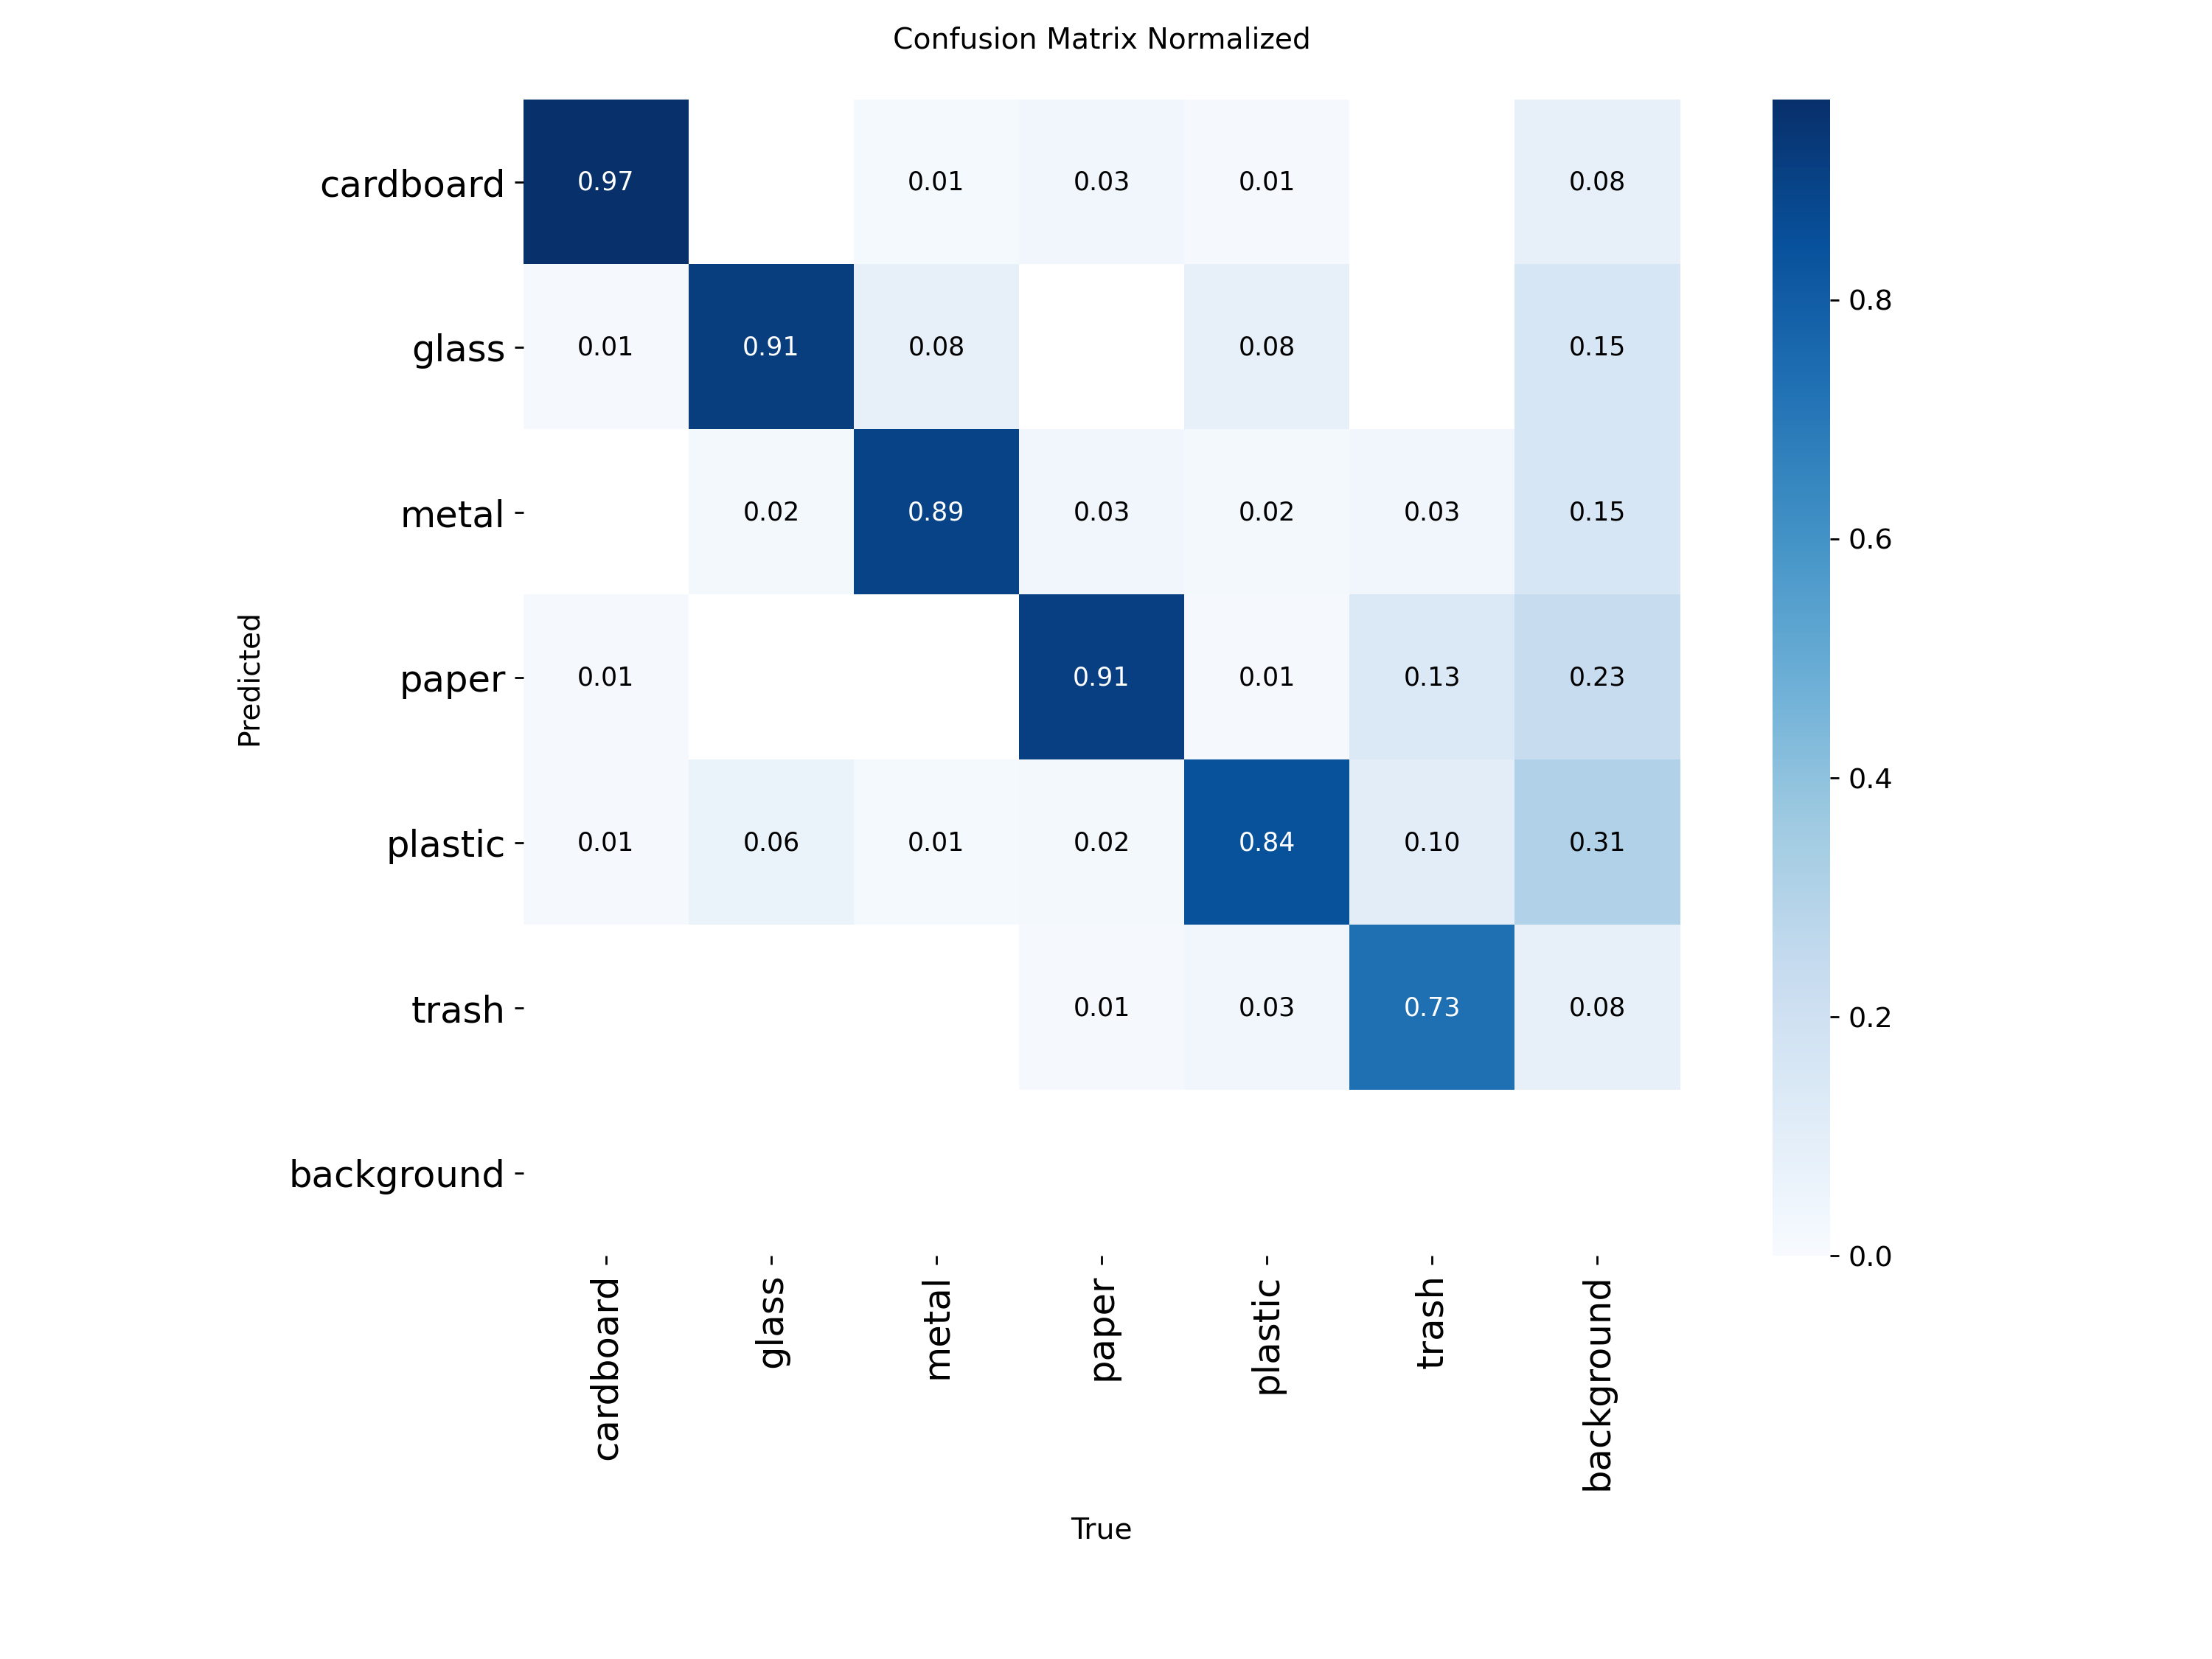

--------------------------------------------------------------------------------

Gráfico: Labels


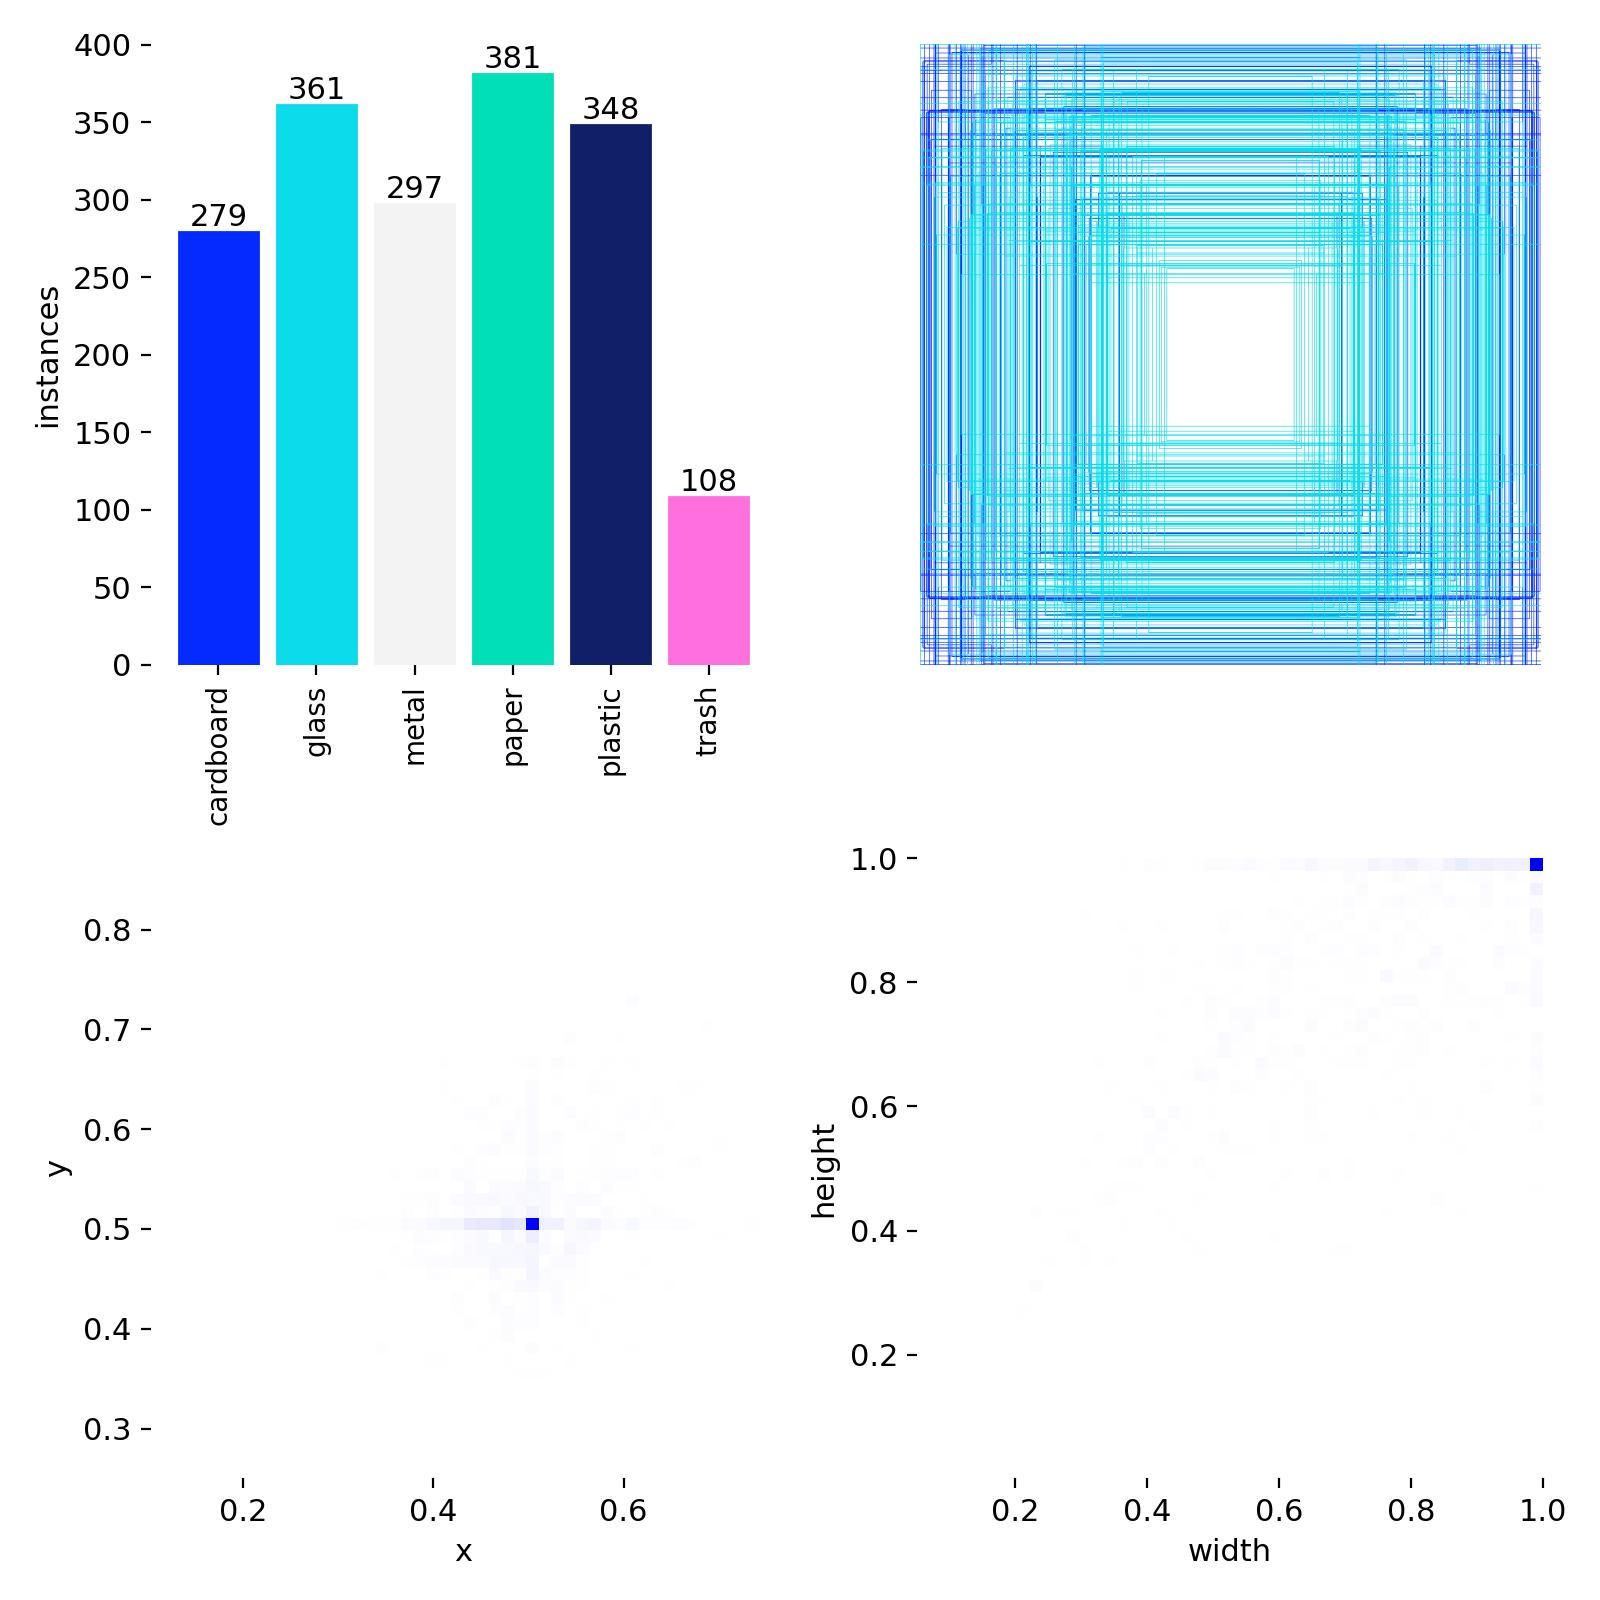

--------------------------------------------------------------------------------

Gráfico: Results


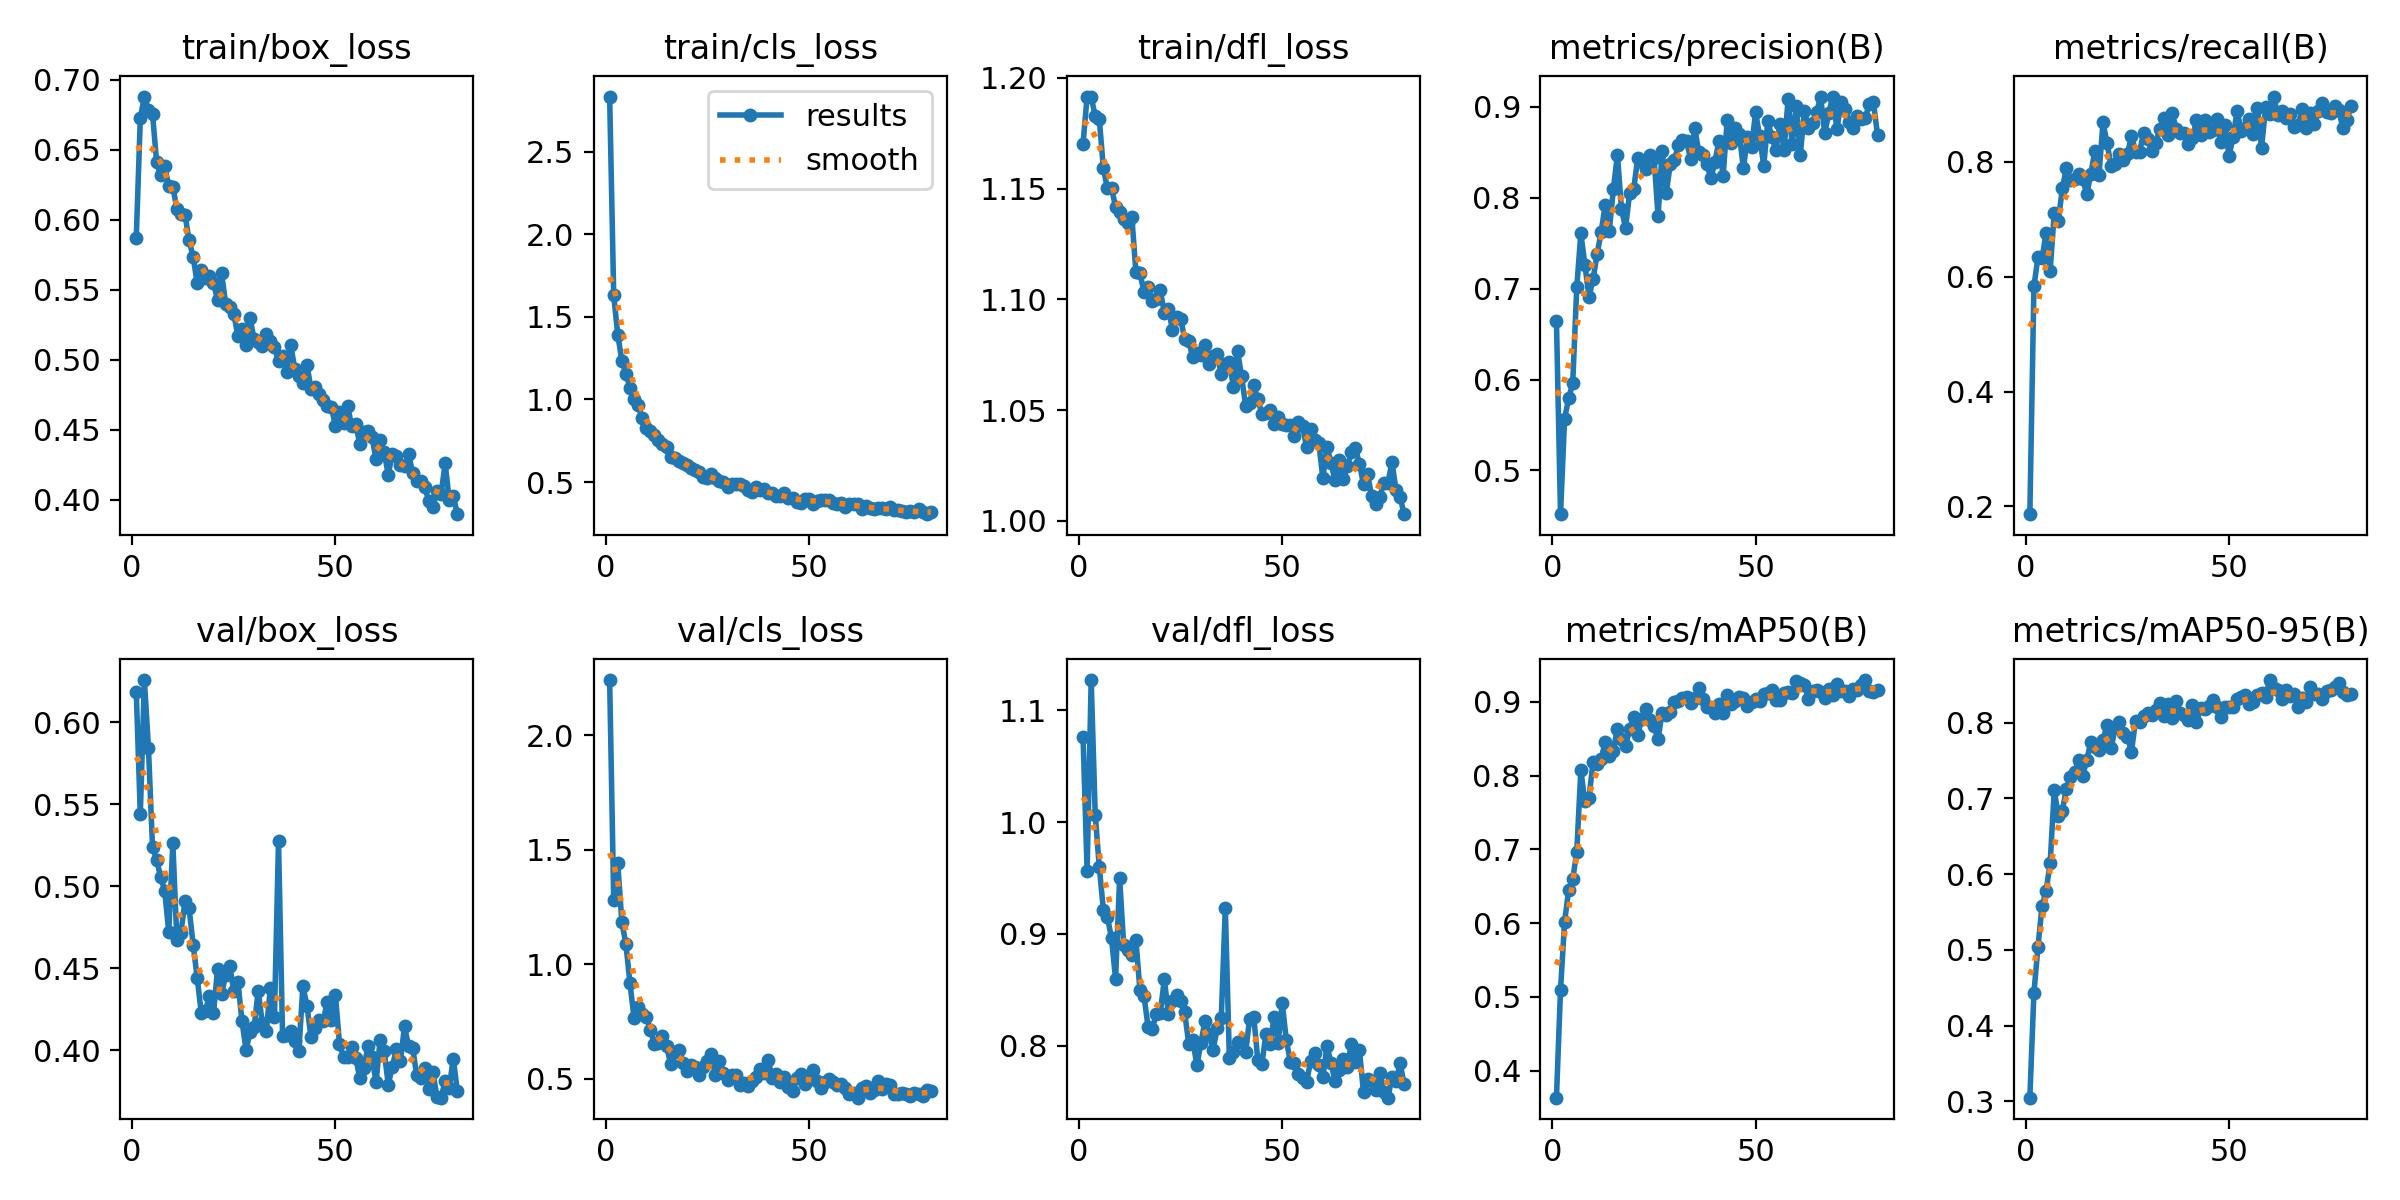

--------------------------------------------------------------------------------



In [ ]:
pasta_treino = "runs/detect/teste_lixo_normal/yolov10n_lixo_normal_finetune"

todas_imagens = glob.glob(os.path.join(pasta_treino, "*.png")) + \
                glob.glob(os.path.join(pasta_treino, "*.jpg"))

# Lógica de filtragem: ignora imagens que mostram exemplos de batches apenas, focando em gráficos de métricas e distribuições
imagens_metricas = [
    caminho for caminho in todas_imagens 
    if "val_batch" not in os.path.basename(caminho) and "train_batch" not in os.path.basename(caminho)
]

# Exibição dinâmica

print(f"Foram encontradas {len(imagens_metricas)} imagens de métricas e distribuições.\n")
print("=" * 80)

# Ordena alfabeticamente para manter a exibição padronizada
for caminho_img in sorted(imagens_metricas):
    nome_arquivo = os.path.basename(caminho_img)
    
    titulo_formatado = nome_arquivo.replace('.png', '').replace('.jpg', '').replace('_', ' ').title()
    
    print(f"Gráfico: {titulo_formatado}")
    
    display(Image(filename=caminho_img, width=1000))
    print("-" * 80 + "\n")